In [176]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path


In [ ]:
FOLDER = Path.cwd().parent
DATA_RUTE = FOLDER / 'Data'

historico_equipos = pd.read_csv(DATA_RUTE / 'historico_equipos.csv', index_col=[0], parse_dates=[0])
historico_equipos.sort_index(inplace=True)

data_x = pd.read_csv(DATA_RUTE / 'X.csv', index_col=[0], parse_dates=[0])
data_x.sort_index(inplace=True)

# Warning por errores en el formato del csv
data_y = pd.read_csv(DATA_RUTE / 'Y.csv', index_col=[0], parse_dates=[0], dayfirst=True, sep=';', decimal=',')
data_y.sort_index(inplace=True)

# Columnas estan invertidas
data_z = pd.read_csv(DATA_RUTE / 'Z.csv', index_col='Date', parse_dates=['Date'])
data_z.sort_index(inplace=True)

In [184]:
historico_equipos.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3530 entries, 2010-01-04 to 2023-08-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Price_X        3530 non-null   float64
 1   Price_Y        3530 non-null   float64
 2   Price_Z        3530 non-null   float64
 3   Price_Equipo1  3530 non-null   float64
 4   Price_Equipo2  3530 non-null   float64
dtypes: float64(5)
memory usage: 165.5 KB


In [185]:
print(historico_equipos.index)

DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2023-08-18', '2023-08-21', '2023-08-22', '2023-08-23',
               '2023-08-24', '2023-08-25', '2023-08-28', '2023-08-29',
               '2023-08-30', '2023-08-31'],
              dtype='datetime64[us]', name='Date', length=3530, freq=None)


In [186]:
historico_equipos.head()

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
Date,,,,,
2010-01-04,80.12,527.5,2225.25,434.73,931.73
2010-01-05,80.59,527.5,2246.50,449.97,968.56
2010-01-06,81.89,527.5,2302.50,444.48,960.51
2010-01-07,81.51,527.5,2306.50,440.90,960.14
2010-01-08,81.37,552.5,2261.25,448.82,949.55


In [195]:
historico_equipos.tail()

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
Date,,,,,
2023-08-25,84.48,554.00,2123.50,450.36,899.65
2023-08-28,84.42,549.00,2116.25,469.03,933.20
2023-08-29,85.49,545.33,2116.25,460.42,901.79
2023-08-30,85.86,543.67,2140.25,464.80,945.40
2023-08-31,86.86,545.00,2165.25,451.73,955.35


In [187]:
print('Datos duplicados', historico_equipos.duplicated().sum(), '\n')

print('----Datos nulos----')
print(historico_equipos.isnull().sum())

Datos duplicados 0 

----Datos nulos----
Price_X          0
Price_Y          0
Price_Z          0
Price_Equipo1    0
Price_Equipo2    0
dtype: int64


In [188]:
historico_equipos.describe().round(2)

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
count,3530.00,3530.00,3530.00,3530.00,3530.00
mean,78.09,555.53,2037.43,460.04,889.98
std,25.19,138.49,373.14,113.68,170.04
min,19.33,257.50,1421.50,208.34,566.00
25%,57.05,482.50,1767.25,398.23,777.70
50%,75.40,541.62,1974.75,451.25,869.78
75%,104.58,620.00,2235.94,515.61,979.12
max,127.98,1062.37,3984.00,855.32,1703.96


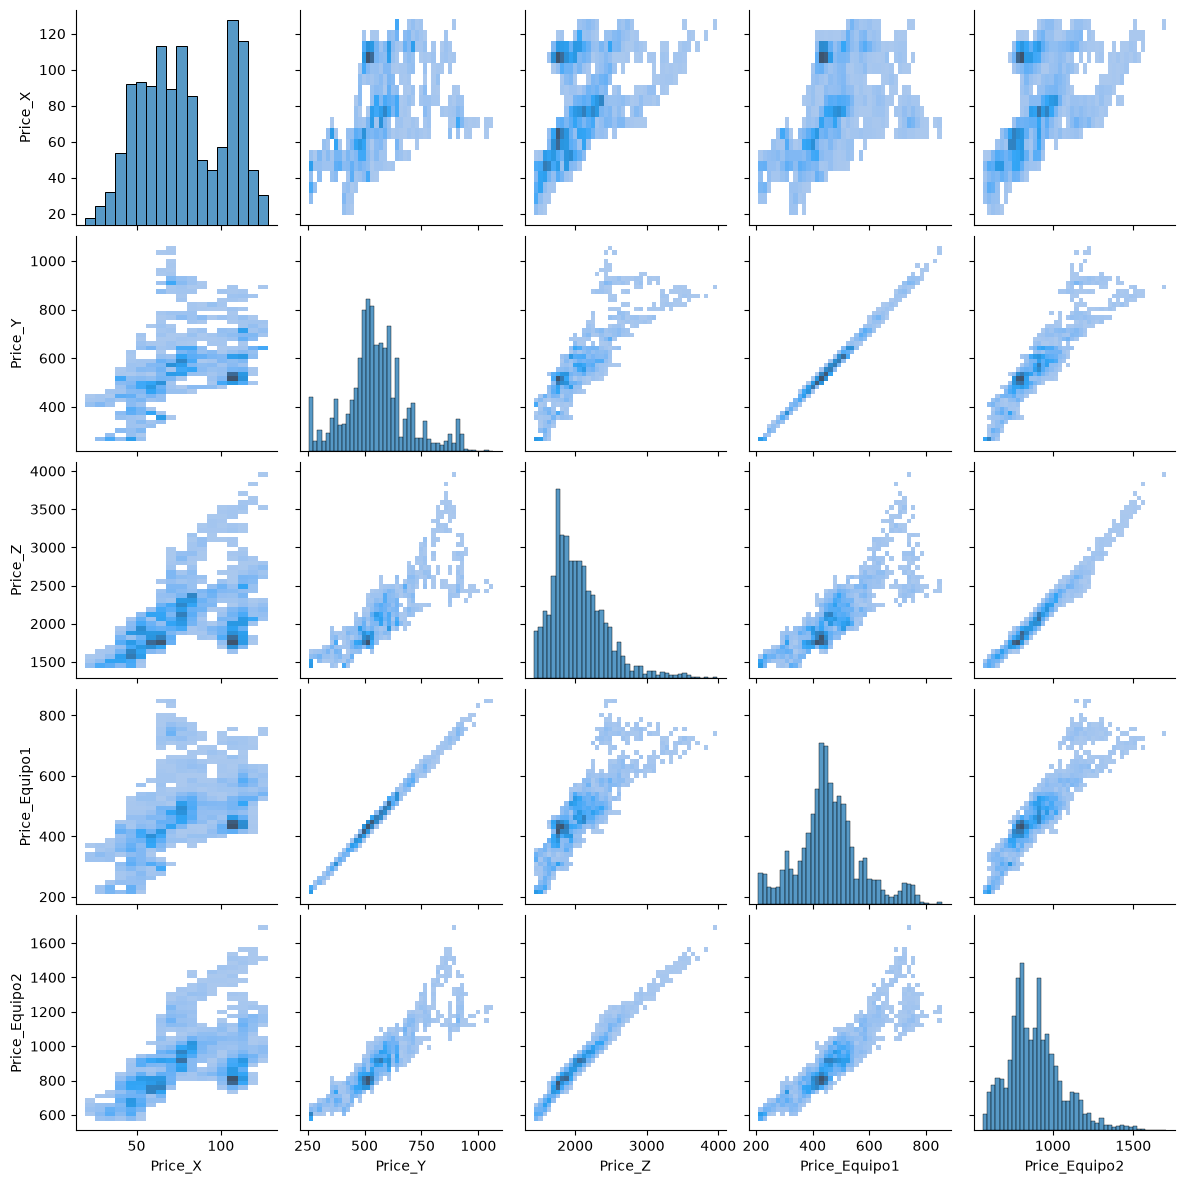

In [191]:
g = sns.pairplot(historico_equipos, kind='hist')
g.figure.set_size_inches(12, 12)

<Axes: title={'center': 'Evolución histórica de precios'}, xlabel='Date'>

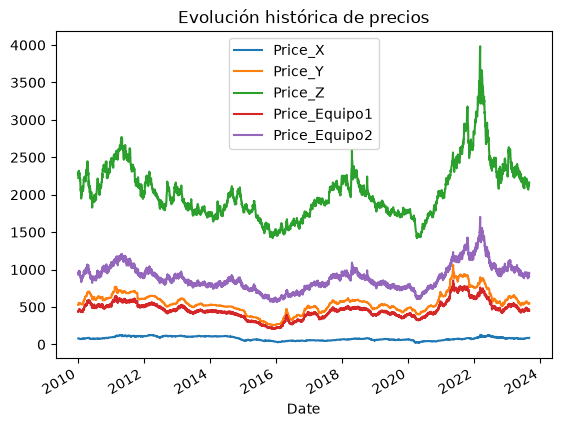

In [223]:
historico_equipos.plot(title='Evolución histórica de precios')

### conclucion de el data set

- Relaciones entre variables
- distrubucion de las graficas (similitudes)

In [228]:
print(data_x.head(),'\n')
print(data_x.tail())

            Price
Date             
1988-06-27  15.10
1988-06-28  15.27
1988-06-29  15.47
1988-06-30  14.85
1988-07-01  14.60 

            Price
Date             
2024-03-28  87.48
2024-04-01  87.42
2024-04-02  88.92
2024-04-03  89.35
2024-04-04  89.18


In [231]:
print(len(data_x.loc['2010-01-01':'2024-12-31']) - len(historico_equipos['Price_X'].loc['2010-01-01':'2024-12-31']))

154


Hay mas datos que el data set completo 

In [229]:
print(data_y.head(),'\n')
print(data_y.tail())

            Price
Date             
2006-07-11  555.0
2006-07-12  555.0
2006-07-13  555.0
2006-07-14  555.0
2006-07-17  555.0 

             Price
Date              
2023-09-06  552.50
2023-09-07  550.00
2023-09-08  545.00
2023-09-11  546.00
2023-09-12  547.33


In [232]:
print(len(data_y.loc['2010-01-01':'2024-12-31']) - len(historico_equipos['Price_X'].loc['2010-01-01':'2024-12-31']))

46


In [230]:
print(data_z.head(),'\n')
print(data_z.tail())

              Price
Date               
2010-01-01  2225.25
2010-01-04  2225.25
2010-01-05  2246.50
2010-01-06  2302.50
2010-01-07  2306.50 

              Price
Date               
2023-08-25  2123.50
2023-08-28  2116.25
2023-08-29  2116.25
2023-08-30  2140.25
2023-08-31  2165.25


In [234]:
print(len(data_z.loc['2010-01-01':'2024-12-31']) - len(historico_equipos['Price_X'].loc['2010-01-01':'2024-12-31']))

35
